# Tree-Based Macroeconomic Regime Classification

Based on:
> Bie, Diebold, He, Li. *Machine Learning and the Yield Curve: Tree-Based Macroeconomic Regime Switching*. (2024).

What this notebook does:
- Loads and merges macroeconomic data from FRED
- Computes rolling 10-year quantile standardization (as in the paper)
- Runs a sequential greedy 2-split tree using Bayesian marginal likelihood as the splitting criterion
- Labels all months into 3 regimes
- Visualizes the tree structure and regime statistics

## 0. Imports

In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gammaln
import pandas_datareader as pdr
import os

## 1. Load & Merge Macroeconomic Data

We load the macroeconomic variables mentioned in the paper (Table 5, pg. 17) using the FRED API. I also included the federal funds effective rate because an LLM suggested I do so.

In [102]:
# User Inputs

os.environ['FRED_API_KEY'] = 'USE YOUR OWN KEY'

'''
Feel free to add/remove any series from this list

From FRED's website:
TB3MS - 3-Month Treasury Bill Secondary Market Rate, Discount Basis
INDPRO - Industrial Production: Total Index
CPIAUCSL - CPI for All Urban Consumers: All Items in U.S. City Average
M2SL - M2 Money Supply
PAYEMS - Total Nonfarm Payroll
UNRATE - Unemployment Rate
WTISPLC - Spot Crude Oil Price: West Texas Intermediate (WTI)
T10Y2YM - 10-Year Treasury Constant Maturity Minus 2-Year Treasury Constant Maturity (Term Spread)
BAMLH0A0HYM2 - ICE BofA US High Yield Index Option-Adjusted Spread (Default Spread)
VIXCLS - CBOE Volatility Index: VIX
FEDFUNDS - Federal Funds Effective Rate
'''

series = ['TB3MS', 'INDPRO', 'CPIAUCSL', 'M2SL', 'PAYEMS', 'UNRATE', 'WTISPLC', 'T10Y2YM', 'BAMLH0A0HYM2', 'VIXCLS', 'FEDFUNDS']

# Data start and end dates
start_date = '1961-08-01'
end_date = '2100-01-01' # you can change this

# Rolling quantile standardization parameters
rolling_window = 120 # 10-year rolling window (pg. 17)

# Tree classification parameters
thresholds = [0.2, 0.4, 0.6, 0.8] # candidate split thresholds (pg. 17)
min_regime_months = 24 # (pg. 11)
max_regimes = 3 # (pg. 11)

In [103]:
# Gets data from FRED API
print('Fetching FRED data...')
raw = pdr.get_data_fred(series, start=start_date, end=end_date)
raw.index = pd.to_datetime(raw.index)
raw = raw.sort_index()
raw = raw.resample('MS').mean()

# Check data
print(f'\nAmount of data:')
for col in raw.columns:
    print(f'{col:20s} | {f'{raw[col].notna().sum()} months':20s} | '
          f'{raw[col].first_valid_index().date()} → {raw[col].last_valid_index().date()}')

print(f'\nMissing values per column:')
print(raw.isnull().sum())

print(f'\nMerged shape: {raw.shape}')

Fetching FRED data...

Amount of data:
TB3MS                | 776 months           | 1961-08-01 → 2026-03-01
INDPRO               | 775 months           | 1961-08-01 → 2026-02-01
CPIAUCSL             | 775 months           | 1961-08-01 → 2026-03-01
M2SL                 | 775 months           | 1961-08-01 → 2026-02-01
PAYEMS               | 776 months           | 1961-08-01 → 2026-03-01
UNRATE               | 775 months           | 1961-08-01 → 2026-03-01
WTISPLC              | 776 months           | 1961-08-01 → 2026-03-01
T10Y2YM              | 598 months           | 1976-06-01 → 2026-03-01
BAMLH0A0HYM2         | 353 months           | 1996-12-01 → 2026-04-01
VIXCLS               | 436 months           | 1990-01-01 → 2026-04-01
FEDFUNDS             | 776 months           | 1961-08-01 → 2026-03-01

Missing values per column:
TB3MS             1
INDPRO            2
CPIAUCSL          2
M2SL              2
PAYEMS            1
UNRATE            2
WTISPLC           1
T10Y2YM         179
BAM

In [104]:
# Clean data
data = raw.loc[start_date:end_date].copy()
data = data.ffill().dropna()

# Check data again
print(f'Final date range: {data.index.min().date()} → {data.index.max().date()}')
print(f'Total months: {len(data)}')

print(f'\nMissing values per column:')
print(data.isnull().sum())

# Preview the data
print(data.head())

Final date range: 1996-12-01 → 2026-04-01
Total months: 353

Missing values per column:
TB3MS           0
INDPRO          0
CPIAUCSL        0
M2SL            0
PAYEMS          0
UNRATE          0
WTISPLC         0
T10Y2YM         0
BAMLH0A0HYM2    0
VIXCLS          0
FEDFUNDS        0
dtype: int64
            TB3MS   INDPRO  CPIAUCSL    M2SL    PAYEMS  UNRATE  WTISPLC  \
DATE                                                                      
1996-12-01   4.91  77.5333     159.1  3818.6  121143.0     5.4    25.39   
1997-01-01   5.03  77.6562     159.4  3834.6  121356.0     5.3    25.17   
1997-02-01   5.01  78.5833     159.7  3846.3  121673.0     5.2    22.21   
1997-03-01   5.14  79.0820     159.8  3861.2  121991.0     5.2    20.99   
1997-04-01   5.16  79.1747     159.9  3877.0  122289.0     5.1    19.72   

            T10Y2YM  BAMLH0A0HYM2     VIXCLS  FEDFUNDS  
DATE                                                    
1996-12-01     0.52      3.130000  19.260952      5.29  
1997

In [105]:
# Map FRED variable names (keys) to the paper's variable names (values)
# Keys = your column name, Values = short label used in the rest of the notebook.

macro_map = {
    'TB3MS': 'DTB3',
    'INDPRO': 'INDPRO',
    'CPIAUCSL': 'CPI',
    'M2SL': 'M2',
    'PAYEMS': 'PAYEMS',
    'UNRATE': 'UNRATE',
    'WTISPLC': 'OILPRICE',
    'T10Y2YM': 'TERM_SPREAD',
    'BAMLH0A0HYM2': 'DEFAULT_SPREAD',
    'VIXCLS': 'VIX',
    'FEDFUNDS': 'FFR'
}

# Rename columns
data = data.rename(columns=macro_map)
macro_cols = list(macro_map.values())

## 2. Compute Year-over-Year Changes
For level series (CPI, industrial production, M2, payrolls, oil price),
we compute YoY percent change as the paper does.
Rate/spread/index series (FFR, UNRATE, T-bill, VIX, term spread, default spread)
are used as-is or as levels.

In [106]:
# Series that need YoY % change transformation (Table 5, pg. 17)
YoY_cols = ['INDPRO', 'CPI', 'M2', 'PAYEMS', 'OILPRICE']

# Apply YoY transformation where needed
for col in YoY_cols:
    if col in data.columns:
        data[col] = data[col].pct_change(12) * 100
        print(f'Applied YoY % change to: {col}')

# Drop NaNs introduced by the YoY transformation
data = data.ffill().dropna()

# Check data
print(f'\nFinal shape after YoY transforms: {data.shape}')
data[macro_cols].describe().round(2)

Applied YoY % change to: INDPRO
Applied YoY % change to: CPI
Applied YoY % change to: M2
Applied YoY % change to: PAYEMS
Applied YoY % change to: OILPRICE

Final shape after YoY transforms: (341, 11)


,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,DEFAULT_SPREAD,VIX,FFR
count,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00,341.00
mean,2.12,0.94,2.53,6.41,0.94,5.53,10.99,0.99,5.27,20.23,2.26
std,2.00,4.28,1.67,4.42,2.45,1.89,40.46,0.96,2.53,7.85,2.12
min,0.01,-17.32,-1.96,-4.63,-13.39,3.40,-74.08,-0.93,2.57,10.13,0.05
25%,0.13,-0.74,1.62,4.48,0.40,4.20,-15.41,0.18,3.59,14.45,0.16
50%,1.58,1.87,2.29,6.10,1.53,4.90,6.60,0.86,4.63,18.89,1.69
75%,4.23,3.21,3.19,7.41,1.92,6.10,33.55,1.80,6.23,23.87,4.48
max,6.17,16.55,8.98,26.78,10.86,14.80,272.93,2.83,20.31,62.67,6.54


## 3. Rolling 10-Year Quantile Standardization
As in the paper, we replace each macro value with its quantile rank within the past 120 months (pg. 17).

In [107]:
def rolling_quantile_standardize(series, window=120):
    """
    For each time t, compute the quantile rank of series[t]
    within the past 'window' observations.
    """
    result = pd.Series(index=series.index, dtype=float)
    for i in range(window-1, len(series)):
        window_data = series.iloc[i-(window-1):i+1].dropna()
        result.iloc[i] = (window_data <= series.iloc[i]).sum() / len(window_data)

    return result

print('Computing rolling quantile standardization...')
data_q = pd.DataFrame(index=data.index)

for col in macro_cols:
    data_q[col] = rolling_quantile_standardize(data[col], window=rolling_window)

# Clean quantile data
data_q = data_q.ffill().dropna()

# Check quantile data
print(f'\nStandardized shape: {data_q.shape}')
data_q.describe().round(2)

Computing rolling quantile standardization...

Standardized shape: (222, 11)


,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,DEFAULT_SPREAD,VIX,FFR
count,222.00,222.00,222.00,222.00,222.00,222.00,222.00,222.00,222.00,222.00,222.00
mean,0.49,0.46,0.52,0.48,0.51,0.47,0.46,0.41,0.41,0.52,0.49
std,0.37,0.29,0.31,0.32,0.34,0.33,0.30,0.31,0.29,0.28,0.38
min,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01
25%,0.12,0.21,0.23,0.18,0.13,0.16,0.19,0.12,0.11,0.30,0.14
50%,0.47,0.42,0.54,0.45,0.54,0.49,0.42,0.38,0.42,0.50,0.35
75%,0.86,0.69,0.78,0.75,0.84,0.71,0.69,0.66,0.61,0.76,0.86
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


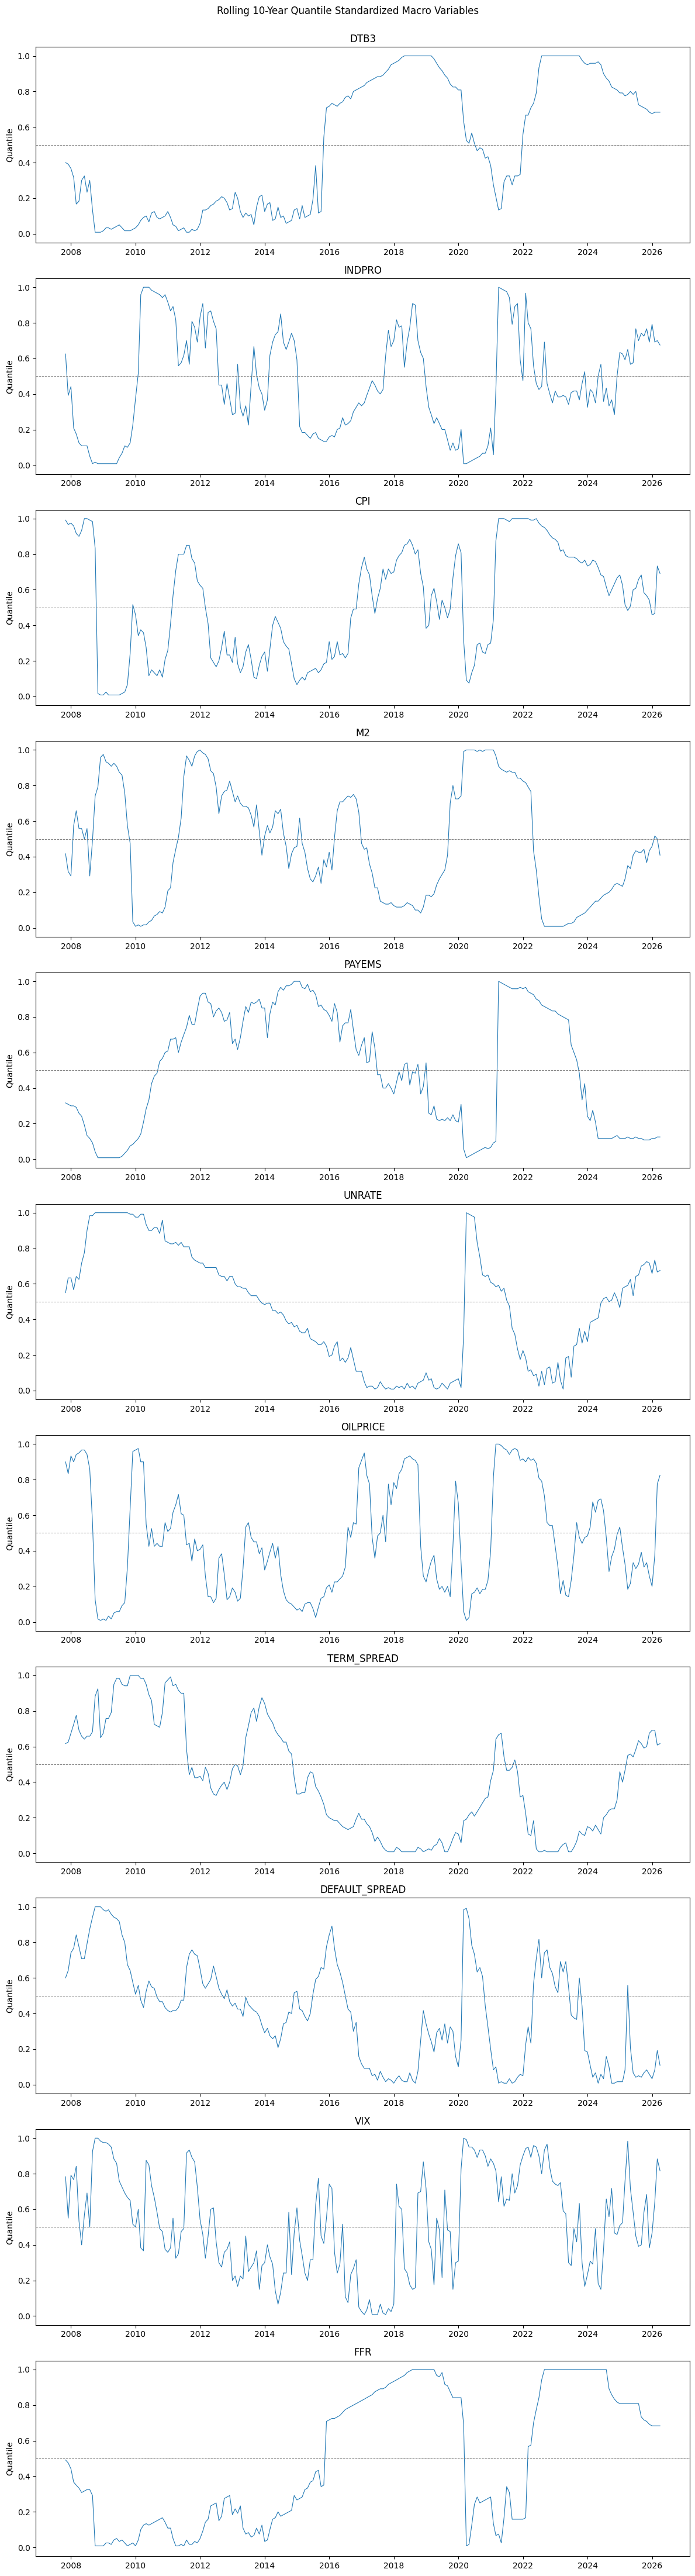

In [108]:
# Plot standardized macro variables
n_cols = len(macro_cols)
fig, axes = plt.subplots(n_cols, 1, figsize=(12, 4*n_cols))

for i, col in enumerate(macro_cols):
    axes[i].plot(data_q.index, data_q[col], lw=0.8)
    axes[i].axhline(0.5, color='gray', lw=0.7, linestyle='--')
    axes[i].set_title(col)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].set_ylabel('Quantile')

plt.suptitle('Rolling 10-Year Quantile Standardized Macro Variables', y=1.0)
plt.tight_layout()
plt.show()

## 4. Bayesian Marginal Likelihood (Splitting Criterion)

Instead of splitting based on the marginal likelihood of a DNS model, as in the paper, we compute the Bayesian marginal likelihood under a Normal-Inverse-Gamma conjugate model:

$$p(Y) = \int p(Y | \mu, \sigma^2) \, p(\mu, \sigma^2) \, d\mu \, d\sigma^2$$

This has a closed-form expression (see below). It naturally penalizes splits that reduce regime size
without improving fit.

**Model:**
* Likelihood - $Y_i \sim \mathcal{N}(\mu, \sigma^2)$: $Y_i$ is a single observation (e.g., the CPI quantile for June 2024). We assume that within any specific economic regime, the macro variable follows a Normal distribution with some mean ($\mu$) and variance ($\sigma^2$).
* Prior for the Mean - $\mu \sim \mathcal{N}(\mu_0, \sigma^2 / \kappa_0)$: Since we don't know the "true" average of the regime, we treat $\mu$ as a random variable. We assume it's centered at our best guess $\mu_0$. The variance is scaled by $\sigma^2$ because if the data is generally very noisy, our guess for the mean should be noisier too.
* Prior for the Variance - $\sigma^2 \sim \text{IG}(\alpha_0, \beta_0)$: The Inverse-Gamma (IG) is the standard distribution for "variance" because it is only defined for positive numbers and has a "fat tail," which accounts for the possibility of sudden high-volatility regimes.

**Prior Hyperparameters:**
* Mean - $\mu_0$
* Precision Scaling - $\kappa_0$
* Shape for Inverse Gamma - $\alpha_0$
* Scale for Inverse Gamma - $\beta_0$

**Posterior Hyperparameters (from Wikipedia, unfortunately):**
* Sample Mean: $$\overline{y} = \frac{1}{n}\sum_{i=1}^n Y_i$$
* Mean (weighted average of prior and data): $$\mu_n = \frac{\kappa_0 \mu_0 + n \overline{y}}{\kappa_0 + n}$$
* Precision Scaling: $$\kappa_n = \kappa_0 + n$$
* Shape for Inverse Gamma: $$\alpha_n = \alpha_0 + \frac{n}{2}$$
* Scale for Inverse Gamma: $$\beta_n = \beta_0 + \frac{1}{2} \sum_{i=1}^n (Y_i - \overline{y})^2 + \frac{n \kappa_0}{\kappa_0 + n} \frac{(\mu_0 - \overline{y})^2}{2}$$

**Marginal Likelihood:** $$p(Y) = \frac{1}{(2\pi)^{n/2}} \sqrt{\frac{\kappa_0}{\kappa_n}} \frac{\Gamma(\alpha_n)}{\Gamma(\alpha_0)} \frac{\beta_0^{\alpha_0}}{\beta_n^{\alpha_n}}$$

In [109]:
# Log marginal likelihood under a Normal-Inverse-Gamma (NIG) conjugate model
def log_marginal_likelihood_nig(Y, mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0):
    # Clean array
    Y = np.asarray(Y, dtype=float)
    Y = Y[np.isfinite(Y)]
    n = len(Y)
    if n < 2: # We need at least 2 points to define a variance
        return -np.inf # -inf ensures the tree rejects splits that create singleton regimes

    # Posterior hyperparameters
    ybar = Y.mean()
    kappa_n = kappa0 + n
    mu_n = (kappa0 * mu0 + n * ybar) / kappa_n
    alpha_n = alpha0 + n / 2.0
    beta_n = (beta0 + np.sum((Y - ybar) ** 2) / 2.0 + (n * kappa0 * (ybar - mu0) ** 2) / (2.0 * kappa_n))

    # Log marginal likelihood
    log_ml = - (n / 2.0) * np.log(2.0 * np.pi) + (1 / 2.0) * np.log(kappa0 / kappa_n) + (gammaln(alpha_n) - gammaln(alpha0)) + alpha0 * np.log(beta0) - alpha_n * np.log(beta_n)

    return log_ml

# Sum of log marginal likelihoods across all regimes
def total_log_ml(regime_labels, target_data, unique_labels=None):
    # Monthly regime labels
    regime_labels = np.asarray(regime_labels)
    if unique_labels is None:
        unique_labels = np.unique(regime_labels)

    # Yields or macro data
    target = np.asarray(target_data)
    if target.ndim == 1:
        target = target.reshape(target.shape, 1)

    # Compute sum
    total = 0.0
    for label in unique_labels:
        mask = (regime_labels == label)

        # Insufficient data
        if mask.sum() < 2:
            return -np.inf

        for col_idx in range(target.shape[1]):
            total += log_marginal_likelihood_nig(target[mask, col_idx])

    return total

print('Bayesian marginal likelihood functions defined.')

Bayesian marginal likelihood functions defined.


## 5. Target Variable Setup
The splitting criterion is evaluated on the target variable(s). For now we use the macro variables themselves as targets, but we could also use yields data.

In [110]:
'''
# Yields as Target Data Setup
YIELD_SERIES = ['DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10', 'DGS30']
yields = pdr.get_data_fred(YIELD_SERIES, start=START_DATE, end=END_DATE)
yields = yields.resample('MS').mean()
yields.columns = ['Y3M', 'Y1Y', 'Y2Y', 'Y5Y', 'Y10Y', 'Y30Y']
yields = yields.ffill().dropna()
yields = yields.loc[data_q.index]  # align to macro dates after cleaning
target_data = yields.values
'''

# Macros as Target Data
common_idx = data_q.index # align everything to common dates
target_data = data.loc[common_idx, macro_cols].values # raw macro values

print(f'Target data shape: {target_data.shape}')
print(f'Macro (split candidates) shape: {data_q.shape}')
print(f'Date range: {common_idx.min().date()} → {common_idx.max().date()}')

Target data shape: (222, 11)
Macro (split candidates) shape: (222, 11)
Date range: 2007-11-01 → 2026-04-01


## 6. Sequential Tree Growing (2 Splits, 3 Regimes)
Greedy search: at each step, we evaluate every candidate
(macro variable $\times$ threshold) on every current leaf node and
pick the one with the highest total marginal likelihood (sec. 2.2.2).

In [111]:
# Search all (variable, threshold) combinations for the best split of a given leaf node
def find_best_split(regime_labels, leaf_label, data_q, target_data, thresholds, min_obs, next_label):
    """
    Parameters:
    regime_labels - regime label array for all observations
    leaf_label - integer label of the leaf node to split
    data_q - DataFrame of standardized macro variables (split candidates)
    target_data - array of target observations (yields or macros)
    thresholds - list of quantile thresholds to try
    min_obs - minimum observations required in each resulting regime
    next_label - integer label to assign to the new (right) child node

    Returns:
    best_macro - column name of the best splitting variable
    best_threshold - quantile threshold of the best split
    best_ml - total log marginal likelihood achieved
    best_labels - updated regime label array after the split
    """
    leaf_mask = (regime_labels == leaf_label)

    # Initialize best guesses
    best_ml = -np.inf
    best_macro = None
    best_threshold = None
    best_labels = None

    # Track all results for diagnostics
    all_results = []

    for macro in data_q.columns:
        for threshold in thresholds:
            # Proposed split: where var < threshold -> leaf_label; where var >= threshold -> next_label
            candidate_labels = regime_labels.copy()
            split_mask = leaf_mask & (data_q[macro].values >= threshold)
            candidate_labels[split_mask] = next_label

            # Check minimum number of observations in both new child nodes
            left_count  = (leaf_mask & (data_q[macro].values < threshold)).sum()
            right_count = (leaf_mask & (data_q[macro].values >= threshold)).sum()
            if left_count < min_obs or right_count < min_obs:
                continue

            # Evaluate total marginal likelihood across all regimes
            ml = total_log_ml(candidate_labels, target_data)

            # Append results
            all_results.append({'macro': macro, 'threshold': threshold, 'ml': ml})

            if ml > best_ml:
                best_ml = ml
                best_macro = macro
                best_threshold = threshold
                best_labels = candidate_labels.copy()

    # Print top 5 candidates
    all_results = sorted(all_results, key=lambda x: x['ml'], reverse=True)
    print(f'\n  Top 5 candidates for Leaf {leaf_label}:')
    for r in all_results[:5]:
        print(f'    {r["macro"]:20s} threshold = {r["threshold"]} | log ML = {r["ml"]:.4f}')

    return best_macro, best_threshold, best_ml, best_labels

print('Split search function defined.')

Split search function defined.


In [112]:
# Grow tree
def grow_tree(data_q, target_data, thresholds, min_obs, max_regimes):
    """
    At each step:
      1. Try splitting every current leaf
      2. Pick the (leaf, variable, threshold) combination with highest total marginal likelihood
      3. Apply the split and record it
      4. Stop when max_regimes is reached
    """
    n = len(data_q) # total number of observations (months)
    regime_labels = np.zeros(n, dtype=int) # start every observation in regime 0
    splits = [] # empty list to record split decisions
    n_regimes = 1 # start with 1 regime
    next_label = 1 # the label to assign to the next new regime

    while n_regimes < max_regimes:
        print(f'\n── Split {len(splits)+1}: Searching across '
              f'{n_regimes} leaf node(s) × '
              f'{len(data_q.columns)} variables × '
              f'{len(thresholds)} thresholds ──')

        best_global_ml = -np.inf
        best_global_macro = None
        best_global_threshold = None
        best_global_labels = None
        best_leaf = None

        current_leaves = np.unique(regime_labels)

        for leaf in current_leaves:
            leaf_size = (regime_labels == leaf).sum()
            if leaf_size < 2 * min_obs:
                print(f'Leaf {leaf}: too small to split ({leaf_size} observations), skipping.')
                continue

            macro, threshold, ml, labels = find_best_split(regime_labels, leaf, data_q, target_data, thresholds, min_obs, next_label)

            if macro is not None:
                if ml > best_global_ml:
                    best_global_ml = ml
                    best_global_macro = macro
                    best_global_threshold = threshold
                    best_global_labels = labels
                    best_leaf = leaf
            else:
                print(f'Leaf {leaf}: no valid split found.')

        if best_global_macro is None:
            print('No valid split found anywhere. Stopping.')
            break

        # Apply the best split
        regime_labels = best_global_labels
        split_info = {
            'number_of_splits': len(splits) + 1,
            'leaf_split': best_leaf,
            'macro_variable': best_global_macro,
            'threshold': best_global_threshold,
            'log_ml': best_global_ml,
            'new_label': next_label
        }
        splits.append(split_info)

        print(f'\nSplit {len(splits)} applied: '
              f'  Leaf {best_leaf} split on {best_global_macro} at {best_global_threshold:.1f}')

        for label in np.unique(regime_labels):
            count = (regime_labels == label).sum()
            print(f'    Regime {label}: {count} months')

        next_label += 1
        n_regimes  += 1

    return regime_labels, splits

print('Tree growing function defined.')

Tree growing function defined.


In [113]:
print('Growing macro-instrumented regime tree...')

regime_labels, splits = grow_tree(
    data_q = data_q,
    target_data = target_data,
    thresholds = thresholds,
    min_obs = min_regime_months,
    max_regimes = max_regimes
)

print('\nTree growing complete.')

Growing macro-instrumented regime tree...

── Split 1: Searching across 1 leaf node(s) × 11 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    FFR                  threshold = 0.4 | log ML = -5814.7900
    FFR                  threshold = 0.6 | log ML = -5893.1178
    DTB3                 threshold = 0.6 | log ML = -5902.5394
    FFR                  threshold = 0.2 | log ML = -5957.9618
    FFR                  threshold = 0.8 | log ML = -5975.7013

Split 1 applied:   Leaf 0 split on FFR at 0.4
    Regime 0: 115 months
    Regime 1: 107 months

── Split 2: Searching across 2 leaf node(s) × 11 variables × 4 thresholds ──

  Top 5 candidates for Leaf 0:
    PAYEMS               threshold = 0.4 | log ML = -5502.2855
    PAYEMS               threshold = 0.6 | log ML = -5530.4983
    DEFAULT_SPREAD       threshold = 0.6 | log ML = -5553.0547
    VIX                  threshold = 0.6 | log ML = -5578.0218
    CPI                  threshold = 0.8 | log ML = -5589.2976

  Top 5 ca

## 7. Results, Tree Structure, and Regime Summary

In [114]:
print('Tree Structure')

for s in splits:
    print(f"\nSplit {s['number_of_splits']}:")
    print(f"  Node split    : Regime {s['leaf_split']}")
    print(f"  Macro Variable: {s['macro_variable']}")
    print(f"  Threshold     : {s['threshold']}")
    print(f"  Log ML        : {s['log_ml']:.4f}")
    print(f"  Left child    : Regime {s['leaf_split']}  "
          f"({s['macro_variable']} < {s['threshold']})")
    print(f"  Right child   : Regime {s['new_label']}  "
          f"({s['macro_variable']} >= {s['threshold']})")
    print()

print('────────────────────────────────────────────')
print('Regime Sizes:')
for lbl in sorted(np.unique(regime_labels)):
    cnt = (regime_labels == lbl).sum()
    pct = cnt / len(regime_labels) * 100
    print(f'  Regime {lbl}: {cnt:4d} months  ({pct:.1f}%)')

Tree Structure

Split 1:
  Node split    : Regime 0
  Macro Variable: FFR
  Threshold     : 0.4
  Log ML        : -5814.7900
  Left child    : Regime 0  (FFR < 0.4)
  Right child   : Regime 1  (FFR >= 0.4)


Split 2:
  Node split    : Regime 0
  Macro Variable: PAYEMS
  Threshold     : 0.4
  Log ML        : -5502.2855
  Left child    : Regime 0  (PAYEMS < 0.4)
  Right child   : Regime 2  (PAYEMS >= 0.4)

────────────────────────────────────────────
Regime Sizes:
  Regime 0:   41 months  (18.5%)
  Regime 1:  107 months  (48.2%)
  Regime 2:   74 months  (33.3%)


## 8. Visualizations

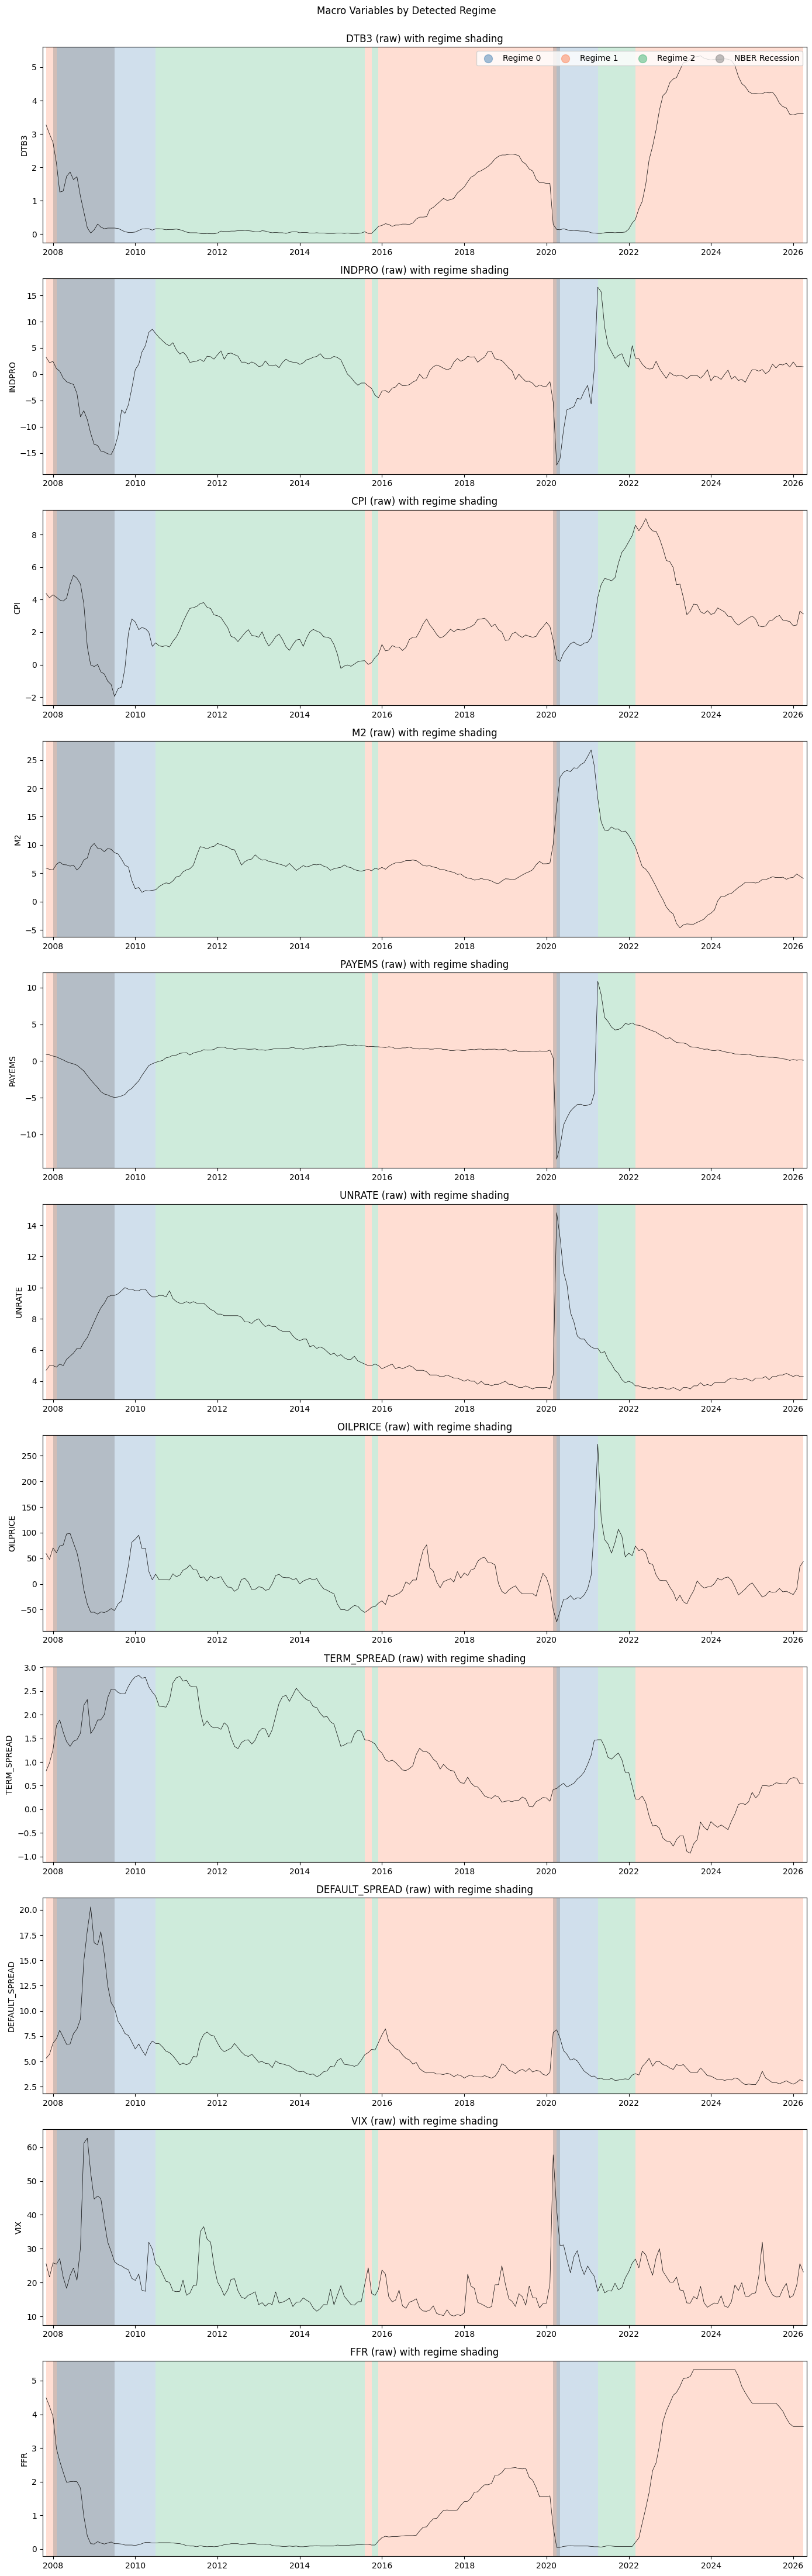

In [115]:
# Get NBER recession dates from FRED
recession = pdr.get_data_fred('USREC', start=start_date, end=end_date)
recession = recession.ffill().fillna(0)

# Plots of Macro Variables Colored by Regime
n_cols_plot = len(macro_cols)
fig, axes = plt.subplots(n_cols_plot, 1, figsize=(14, 4 * n_cols_plot))
colors = {0: 'steelblue', 1: 'coral', 2: 'mediumseagreen', 3: 'orchid', 4: 'goldenrod'}

if n_cols_plot == 1:
    axes = [axes]

for ax, col in zip(axes, macro_cols):
    ax.plot(common_idx, data.loc[common_idx, col], color='black', lw=0.5, zorder=2)

    # Shade background by regime
    for label in np.unique(regime_labels):
        mask = (regime_labels == label)
        regime_dates = common_idx[mask]

        # Find contiguous blocks
        in_block = False
        block_start = None
        for i, date in enumerate(common_idx):
            if mask[i] and not in_block:
                in_block = True
                block_start = date
            # If this month does not belong to the current regime and we were in a block, the block just ended
            elif not mask[i] and in_block:
                in_block = False
                ax.axvspan(block_start, date, alpha=0.25, color=colors[label], lw=0) # Draw the span from `block_start` to `date`
        # Close any open block at the end of the sample
        if in_block:
            ax.axvspan(block_start, common_idx[-1], alpha=0.25, color=colors[label], lw=0)

    # Shade NBER recessions
    in_recession = False
    rec_start = None
    for date, val in recession.iterrows():
        if val['USREC'] == 1 and not in_recession:
            in_recession = True
            rec_start = date
        elif val['USREC'] == 0 and in_recession:
            in_recession = False
            ax.axvspan(rec_start, date, alpha=0.35, color='grey', lw=0, zorder=1)
    # Close any open recession at end of sample
    if in_recession:
        ax.axvspan(rec_start, recession.index[-1], alpha=0.25, color='grey', lw=0, zorder=1)

    ax.set_xlim(common_idx.min() - pd.DateOffset(months=1), common_idx.max() + pd.DateOffset(months=1))
    ax.set_ylabel(col)
    ax.set_title(f'{col} (raw) with regime shading')

# Legend
for label in np.unique(regime_labels):
    axes[0].scatter([], [], color=colors[label], alpha=0.5, label=f'Regime {label}', s=100)
axes[0].scatter([], [], color='grey', alpha=0.5, label='NBER Recession', s=100)
axes[0].legend(loc='upper right', ncol=len(np.unique(regime_labels)) + 1)

plt.suptitle('Macro Variables by Detected Regime', y=1.0)
plt.tight_layout()
plt.show()

## 9. Data Analysis and Statistics

In [116]:
# Record everything in one table
results = pd.DataFrame(index=common_idx)
results[macro_cols] = data.loc[common_idx, macro_cols] # raw values
results[[f'{col}_q' for col in macro_cols]] = data_q.loc[common_idx] # quantile values
results['regime'] = regime_labels

# Preview
results.head()

,DTB3,INDPRO,CPI,M2,PAYEMS,UNRATE,OILPRICE,TERM_SPREAD,DEFAULT_SPREAD,VIX,...,CPI_q,M2_q,PAYEMS_q,UNRATE_q,OILPRICE_q,TERM_SPREAD_q,DEFAULT_SPREAD_q,VIX_q,FFR_q,regime
DATE,,,,,,,,,,,,,,,,,,,,,
2007-11-01,3.27,3.208767,4.373267,5.917126,0.897417,4.7,59.373421,0.81,5.310909,25.582381,...,0.991667,0.416667,0.316667,0.550000,0.900000,0.616667,0.600000,0.783333,0.491667,1
2007-12-01,3.00,2.202978,4.108813,5.703309,0.834979,5.0,47.880058,0.98,5.694500,21.651000,...,0.966667,0.316667,0.308333,0.633333,0.833333,0.625000,0.641667,0.550000,0.475000,1
2008-01-01,2.75,2.414193,4.294696,5.608081,0.668500,5.0,70.331684,1.26,6.796818,25.816190,...,0.975000,0.291667,0.300000,0.633333,0.933333,0.675000,0.741667,0.791667,0.441667,1
2008-02-01,2.12,1.060280,4.142959,6.583687,0.559029,4.9,60.901114,1.77,7.245238,25.456000,...,0.958333,0.575000,0.300000,0.566667,0.900000,0.725000,0.766667,0.766667,0.366667,0
2008-03-01,1.26,0.573426,3.974904,7.000363,0.344742,5.1,74.306473,1.89,8.083000,27.103500,...,0.916667,0.658333,0.291667,0.641667,0.941667,0.775000,0.841667,0.841667,0.350000,0


In [117]:
# Recession Overlap Statistics
print('Recession Overlap Statistics:')

recession = recession.reindex(common_idx, method='ffill').fillna(0)
rec_mask = recession['USREC'].values == 1
total_rec_months = rec_mask.sum()
total_months = len(common_idx)

print(f'\n  Total months in sample: {total_months}')
print(f'  Total recession months: {total_rec_months} ({total_rec_months/total_months*100:.1f}%)')

for label in sorted(np.unique(regime_labels)):
    regime_mask = (regime_labels == label)
    regime_months = regime_mask.sum()

    # Months that are both in this regime AND in recession
    overlap = (regime_mask & rec_mask).sum()

    # % of this regime that is recession
    pct_of_regime = overlap / regime_months * 100

    # % of all recessions captured by this regime
    pct_of_rec = overlap / total_rec_months * 100

    print(f'\nRegime {label} ({regime_months:3d} months):')
    print(f'  Recession months: {overlap}')
    print(f'  % of regime in recession: {pct_of_regime:.1f}%')
    print(f'  % of recessions captured: {pct_of_rec:.1f}%')

Recession Overlap Statistics:

  Total months in sample: 222
  Total recession months: 20 (9.0%)

Regime 0 ( 41 months):
  Recession months: 18
  % of regime in recession: 43.9%
  % of recessions captured: 90.0%

Regime 1 (107 months):
  Recession months: 2
  % of regime in recession: 1.9%
  % of recessions captured: 10.0%

Regime 2 ( 74 months):
  Recession months: 0
  % of regime in recession: 0.0%
  % of recessions captured: 0.0%


In [118]:
# Regime Statistics Table
print('Regime Statistics (with raw macro values):\n')
stat_rows = []
for label in sorted(np.unique(regime_labels)):
    mask = (regime_labels == label)
    row = {'Regime': label, 'N months': mask.sum()}
    for col in macro_cols:
        vals = data.loc[common_idx[mask], col]
        row[f'{col} mean'] = round(vals.mean(), 3)
        row[f'{col} std']  = round(vals.std(), 3)
    stat_rows.append(row)

stats_df = pd.DataFrame(stat_rows).set_index('Regime')
stats_df

Regime Statistics (with raw macro values):



,N months,DTB3 mean,DTB3 std,INDPRO mean,INDPRO std,CPI mean,CPI std,M2 mean,M2 std,PAYEMS mean,...,OILPRICE mean,OILPRICE std,TERM_SPREAD mean,TERM_SPREAD std,DEFAULT_SPREAD mean,DEFAULT_SPREAD std,VIX mean,VIX std,FFR mean,FFR std
Regime,,,,,,,,,,,,,,,,,,,,,
0,41,0.424,0.608,-5.667,6.779,1.577,1.979,11.349,8.222,-3.859,...,7.279,57.533,1.738,0.794,8.651,4.369,29.604,10.940,0.562,0.849
1,107,2.645,1.755,0.300,1.952,3.002,1.927,3.692,3.247,1.632,...,3.710,29.325,0.327,0.578,4.146,1.156,17.703,6.288,2.699,1.789
2,74,0.065,0.052,3.170,3.045,2.343,1.857,7.561,2.968,2.188,...,12.924,47.441,1.820,0.529,4.989,1.239,17.938,5.085,0.113,0.036


## 10. Save Results

In [119]:
# Save regime labels and standardized macro to CSV
out = results[['regime'] + macro_cols].copy()
out.to_csv('regime_labels.csv')
print('Saved: regime_labels.csv')

# Save split summary
splits_df = pd.DataFrame(splits)
splits_df.to_csv('regime_tree_splits.csv', index=False)
print('Saved: regime_tree_splits.csv')

splits_df

Saved: regime_labels.csv
Saved: regime_tree_splits.csv


,number_of_splits,leaf_split,macro_variable,threshold,log_ml,new_label
0,1,0,FFR,0.4,-5814.790005,1
1,2,0,PAYEMS,0.4,-5502.285501,2
